In [2]:
# import pandas as pd
import polars as pl
df_trips_with_weather = pl.scan_parquet('../data_engineer/data/intermediate/fact_trips_with_weather.parquet')
print(df_trips_with_weather.collect_schema())

Schema([('temperature_2m', Float64), ('apparent_temperature', Float64), ('precipitation', Float64), ('snowfall', Float64), ('windspeed_10m', Float64), ('weather_category', String), ('trip_id', Int64), ('pickup_location_id', Int32), ('dropoff_location_id', Int32), ('pickup_datetime', Datetime(time_unit='us', time_zone=None)), ('dropoff_datetime', Datetime(time_unit='us', time_zone=None)), ('pickup_hour_key', Datetime(time_unit='us', time_zone=None)), ('passenger_count', Int32), ('trip_distance', Float64), ('trip_duration_min', Float64), ('avg_speed_mph', Float64), ('fare_amount', Float64), ('tip_amount', Float64), ('total_amount', Float64), ('tip_rate_pct', Float64), ('payment_type', Int32), ('pickup_hour', Int64), ('pickup_day_of_week', Int64), ('pickup_month', Int64), ('time_of_day', String), ('is_rush_hour', Boolean), ('is_weekend', Boolean), ('pickup_zone', String), ('pickup_borough', String), ('pickup_service_zone', String), ('dropoff_zone', String), ('dropoff_borough', String)])


In [3]:
sample = df_trips_with_weather.head(1000).collect
sample

<bound method LazyFrame.collect of <LazyFrame at 0x77FAECA19990>>

In [4]:
df_trips = pl.scan_parquet('../data_engineer/data/intermediate/fact_trips.parquet')
df_trips.collect_schema()

Schema([('trip_id', Int64),
        ('pickup_location_id', Int32),
        ('dropoff_location_id', Int32),
        ('pickup_datetime', Datetime(time_unit='us', time_zone=None)),
        ('dropoff_datetime', Datetime(time_unit='us', time_zone=None)),
        ('pickup_hour_key', Datetime(time_unit='us', time_zone=None)),
        ('passenger_count', Int32),
        ('trip_distance', Float64),
        ('trip_duration_min', Float64),
        ('avg_speed_mph', Float64),
        ('fare_amount', Float64),
        ('tip_amount', Float64),
        ('total_amount', Float64),
        ('tip_rate_pct', Float64),
        ('payment_type', Int32),
        ('pickup_hour', Int64),
        ('pickup_day_of_week', Int64),
        ('pickup_month', Int64),
        ('time_of_day', String),
        ('is_rush_hour', Boolean),
        ('is_weekend', Boolean),
        ('pickup_zone', String),
        ('pickup_borough', String),
        ('pickup_service_zone', String),
        ('dropoff_zone', String),
        ('dr

In [5]:
nulls = df_trips.null_count().collect()
print(nulls)

shape: (1, 26)
┌─────────┬────────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬───────────┐
│ trip_id ┆ pickup_loc ┆ dropoff_l ┆ pickup_da ┆ … ┆ pickup_bo ┆ pickup_se ┆ dropoff_z ┆ dropoff_b │
│ ---     ┆ ation_id   ┆ ocation_i ┆ tetime    ┆   ┆ rough     ┆ rvice_zon ┆ one       ┆ orough    │
│ u32     ┆ ---        ┆ d         ┆ ---       ┆   ┆ ---       ┆ e         ┆ ---       ┆ ---       │
│         ┆ u32        ┆ ---       ┆ u32       ┆   ┆ u32       ┆ ---       ┆ u32       ┆ u32       │
│         ┆            ┆ u32       ┆           ┆   ┆           ┆ u32       ┆           ┆           │
╞═════════╪════════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
│ 0       ┆ 0          ┆ 0         ┆ 0         ┆ … ┆ 0         ┆ 0         ┆ 0         ┆ 0         │
└─────────┴────────────┴───────────┴───────────┴───┴───────────┴───────────┴───────────┴───────────┘


In [6]:
sample_trip = (
    df_trips
    .with_row_count()
    .filter(pl.col("row_nr") % 200 == 0)
    .drop("row_nr")
    .collect()
    .to_pandas()
)


/tmp/ipykernel_1166/2200174858.py:3: DeprecationWarning: `LazyFrame.with_row_count` is deprecated; use `LazyFrame.with_row_index` instead. Note that the default column name has changed from 'row_nr' to 'index'.
  .with_row_count()


In [8]:
sample_trip['pickup_borough'].value_counts()

pickup_borough
Manhattan        63890
Queens            7207
Brooklyn          1266
Bronx              422
EWR                  6
Staten Island        1
Name: count, dtype: int64

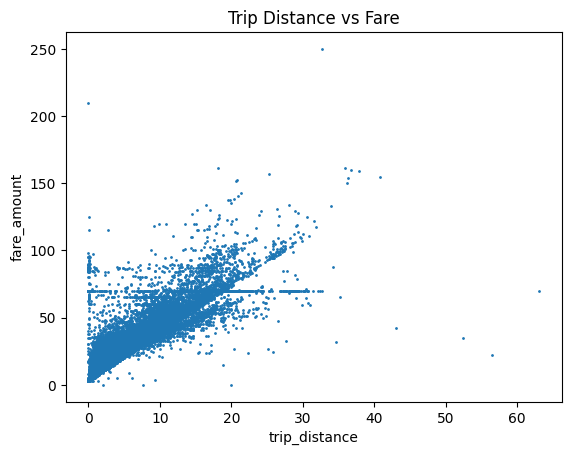

In [252]:
import matplotlib.pyplot as plt

plt.scatter(
    sample_trip["trip_distance"],
    sample_trip["fare_amount"],
    s=1
)

plt.xlabel("trip_distance")
plt.ylabel("fare_amount")
plt.title("Trip Distance vs Fare")

plt.show()

In [253]:
sample_trip.info()

<class 'pandas.DataFrame'>
RangeIndex: 72792 entries, 0 to 72791
Data columns (total 26 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   trip_id              72792 non-null  int64         
 1   pickup_location_id   72792 non-null  int32         
 2   dropoff_location_id  72792 non-null  int32         
 3   pickup_datetime      72792 non-null  datetime64[us]
 4   dropoff_datetime     72792 non-null  datetime64[us]
 5   pickup_hour_key      72792 non-null  datetime64[us]
 6   passenger_count      72792 non-null  int32         
 7   trip_distance        72792 non-null  float64       
 8   trip_duration_min    72792 non-null  float64       
 9   avg_speed_mph        72792 non-null  float64       
 10  fare_amount          72792 non-null  float64       
 11  tip_amount           72792 non-null  float64       
 12  total_amount         72792 non-null  float64       
 13  tip_rate_pct         72792 non-null  float

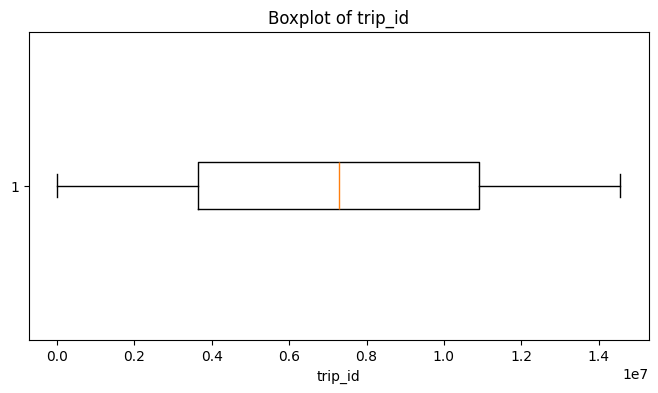

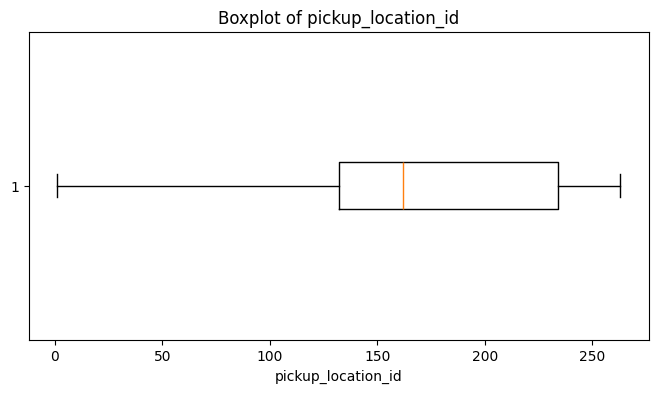

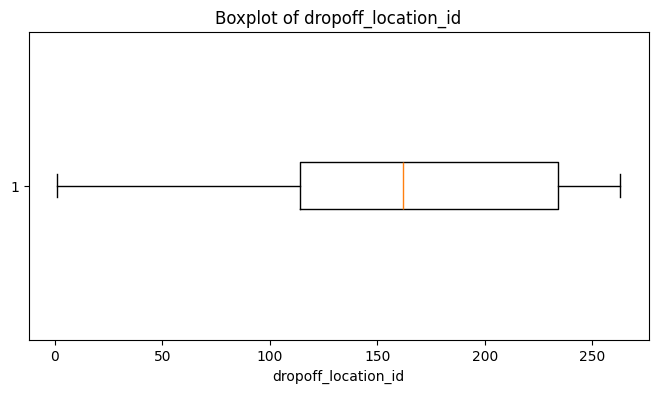

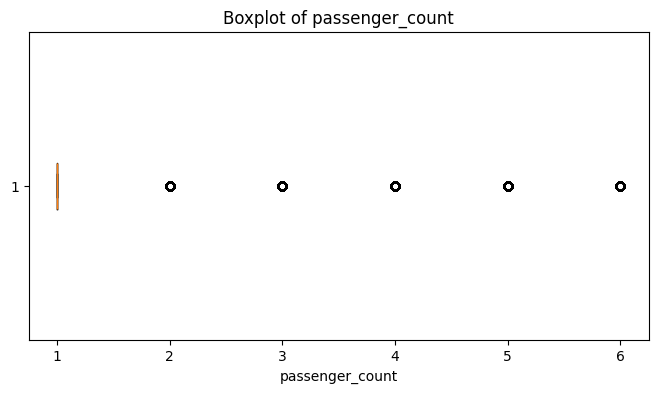

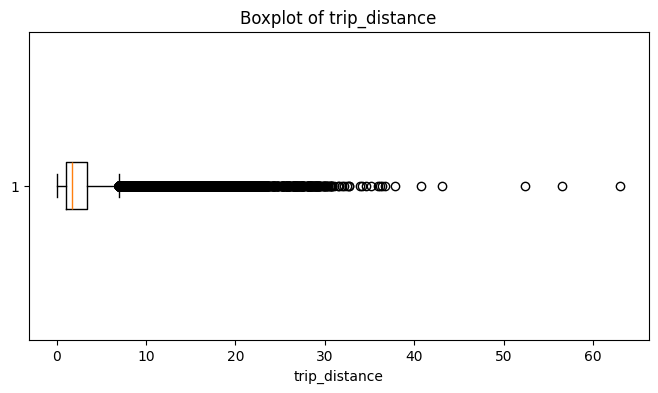

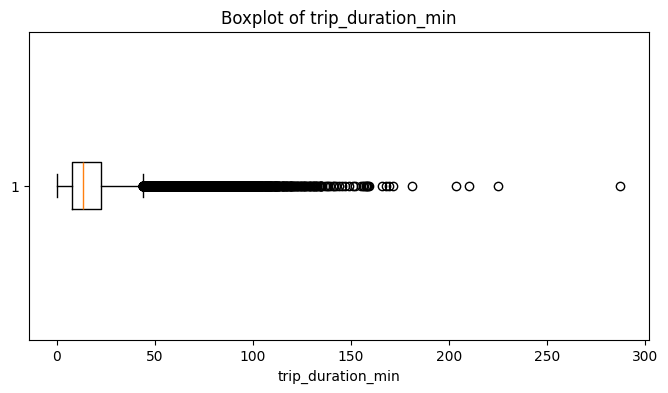

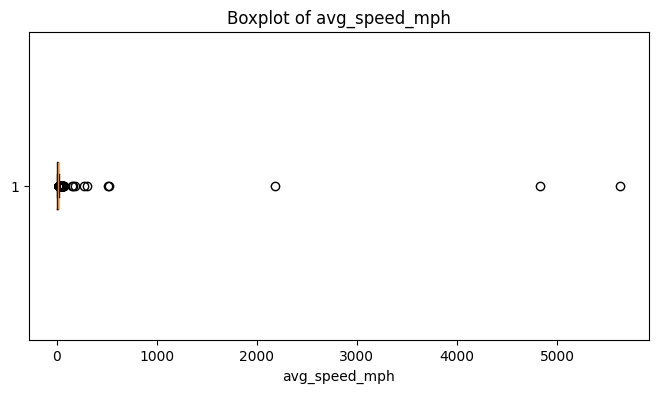

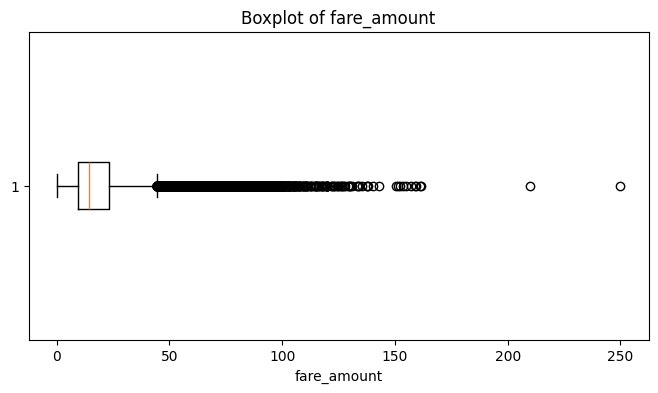

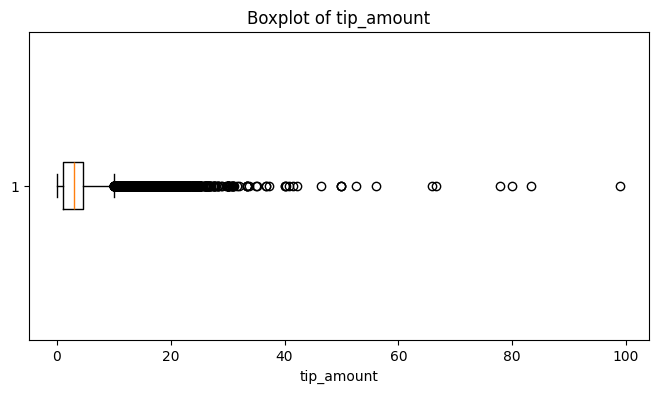

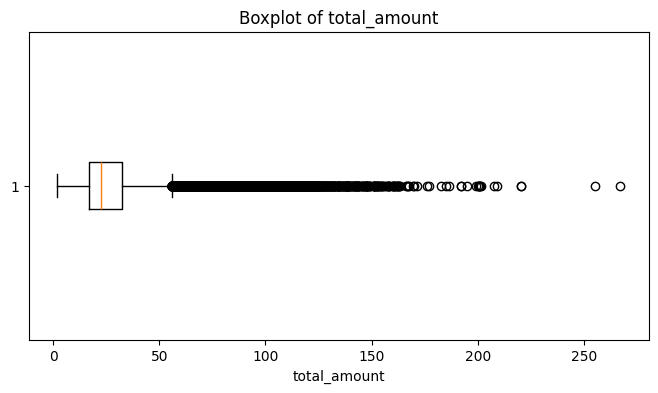

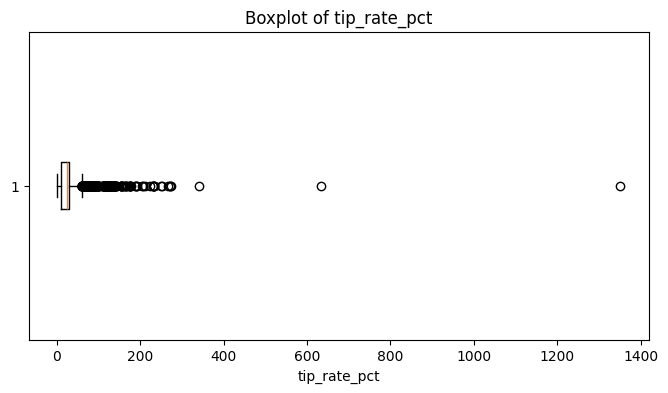

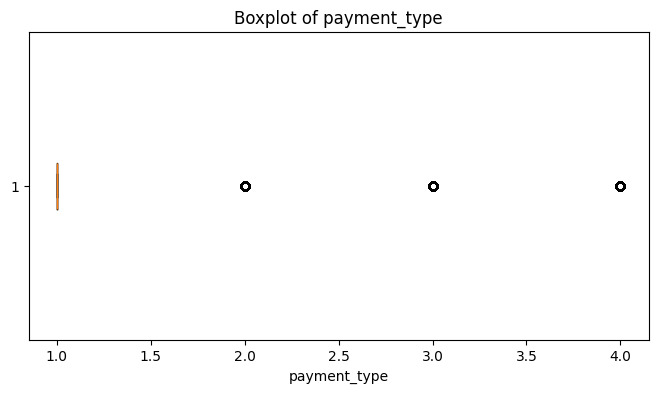

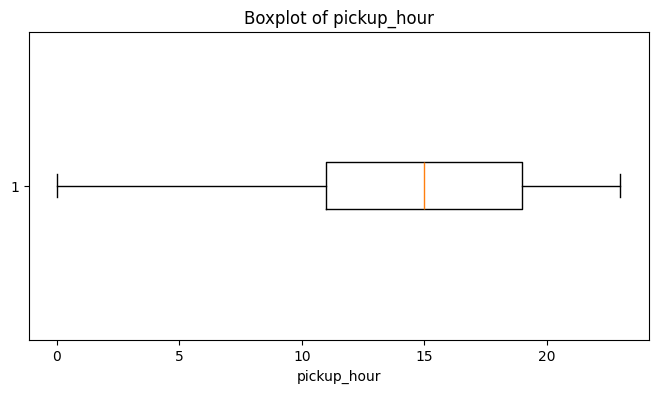

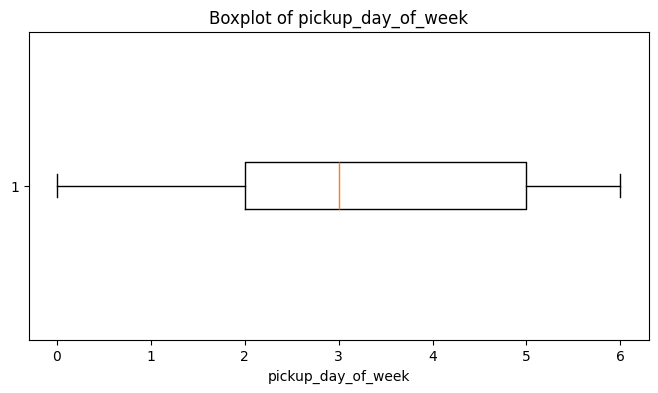

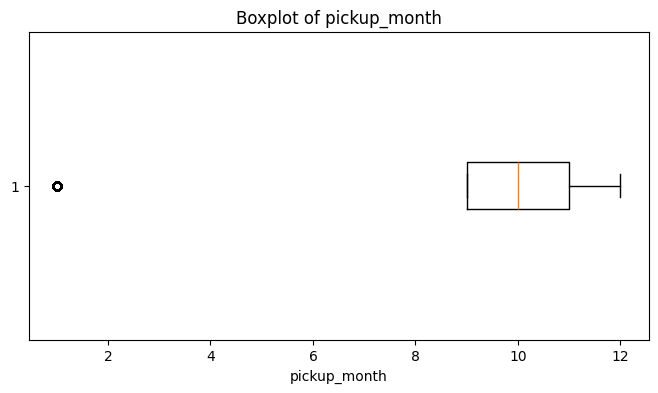

In [254]:
# select numeric columns only
numeric_cols = sample_trip.select_dtypes(include="number").columns

# create boxplot for each numeric column
for col in numeric_cols:
    plt.figure(figsize=(8, 4))

    plt.boxplot(sample_trip[col].dropna(), vert=False)

    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)

    plt.show()

In [255]:
# import matplotlib.pyplot as plt
# import numpy as np

# numeric_cols = sample.select_dtypes(include="number").columns

# for col in numeric_cols:

#     # remove extreme outliers for visualization only
#     q1 = sample[col].quantile(0.25)
#     q3 = sample[col].quantile(0.75)
#     iqr = q3 - q1

#     lower = q1 - 1.5 * iqr
#     upper = q3 + 1.5 * iqr

#     filtered = sample[
#         (sample[col] >= lower) &
#         (sample[col] <= upper)
#     ][col].dropna()

#     plt.figure(figsize=(8, 4))

#     plt.boxplot(filtered, vert=False)

#     plt.title(f"Boxplot of {col}")
#     plt.xlabel(col)

#     plt.show()

In [256]:
# cluster_features = [
#     "trip_distance",
#     "trip_duration_min",
#     "avg_speed_mph",
#     "fare_amount",
#     "tip_rate_pct",
#     "passenger_count",
#     "pickup_hour"
# ]

In [257]:
# sample_trip = [
#     (sample_trip["trip_distance"] > 0) &
#     (sample_trip["trip_duration_min"] > 0) &
#     (sample_trip["fare_amount"] > 0)
# ]

In [258]:
cluster_features_outlier_check = [
    "trip_distance",
    "trip_duration_min",
    "avg_speed_mph",
    "fare_amount",
    "tip_rate_pct",
    "pickup_hour"
]

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = sample_trip.select_dtypes(include="number").corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Heatmap")

plt.show()

In [260]:
# import numpy as np

# # correlation matrix
# corr_matrix = sample_trip.select_dtypes(include="number").corr()

# # threshold
# threshold = 0.7

# # extract high correlations
# high_corr = []

# for i in range(len(corr_matrix.columns)):
#     for j in range(i):

#         corr_value = corr_matrix.iloc[i, j]

#         if abs(corr_value) >= threshold:

#             col1 = corr_matrix.columns[i]
#             col2 = corr_matrix.columns[j]

#             high_corr.append(
#                 (col1, col2, corr_value)
#             )

# # print results
# print(f"Highly correlated features (>|{threshold}|):\n")

# for col1, col2, corr_value in high_corr:
#     print(f"{col1:<25} <-> {col2:<25} : {corr_value:.3f}")

In [261]:
# import matplotlib.pyplot as plt
# import numpy as np


# for col in cluster_features_outlier_check:

#     # remove extreme outliers for visualization only
#     q1 = sample_trip[col].quantile(0.25)
#     q3 = sample_trip[col].quantile(0.75)
#     iqr = q3 - q1

#     lower = q1 - 1.5 * iqr
#     upper = q3 + 1.5 * iqr

#     filtered = sample_trip[
#         (sample_trip[col] >= lower) &
#         (sample_trip[col] <= upper)
#     ][col].dropna()

#     plt.figure(figsize=(8, 4))

#     plt.boxplot(filtered, vert=False)

#     plt.title(f"Boxplot of {col}")
#     plt.xlabel(col)

#     plt.show()

In [262]:
features = [
    "trip_distance",
    "trip_duration_min",
    "fare_amount",
    "tip_rate_pct",
    "avg_speed_mph"
]

for col in features:

    q1 = sample_trip[col].quantile(0.25)
    q3 = sample_trip[col].quantile(0.75)

    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    sample_trip = sample_trip[
        (sample_trip[col] >= lower) &
        (sample_trip[col] <= upper)
    ]

log transfrom for skewd features

In [263]:
import numpy as np

sample_trip["hour_sin"] = np.sin(
    2 * np.pi * sample_trip["pickup_hour"] / 24
)

sample_trip["hour_cos"] = np.cos(
    2 * np.pi * sample_trip["pickup_hour"] / 24
)

In [264]:
import numpy as np

sample_trip["trip_distance"] = np.log1p(sample_trip["trip_distance"])
sample_trip["fare_amount"] = np.log1p(sample_trip["fare_amount"])
sample_trip["trip_duration_min"] = np.log1p(sample_trip["trip_duration_min"])

In [265]:
cluster_features = [
    "trip_distance",
    "avg_speed_mph",
    "tip_rate_pct",
    # "hour_sin",
    # "hour_cos"
]

In [266]:
# import seaborn as sns
# import matplotlib.pyplot as plt

# corr = sample_trip.select_dtypes(include="number").corr()

# plt.figure(figsize=(12, 8))

# sns.heatmap(
#     corr,
#     annot=True,
#     cmap="coolwarm",
#     fmt=".2f"
# )

# plt.title("Feature Correlation Heatmap")

# plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler

X = sample_trip[cluster_features]
 
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

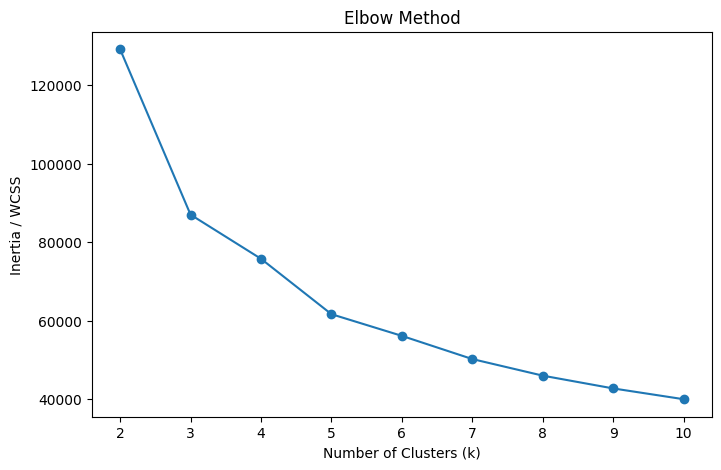

In [268]:
from sklearn.cluster import MiniBatchKMeans
import matplotlib.pyplot as plt

inertias = []
k_values = range(2, 11)

for k in k_values:

    kmeans = MiniBatchKMeans(
        n_clusters=k,
        random_state=42,
        batch_size=10000
    )

    kmeans.fit(X_scaled)

    inertias.append(kmeans.inertia_)

# plot elbow curve
plt.figure(figsize=(8, 5))

plt.plot(k_values, inertias, marker="o")

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia / WCSS")
plt.title("Elbow Method")

plt.show()

In [269]:
from sklearn.cluster import MiniBatchKMeans

kmeans = MiniBatchKMeans(
    n_clusters=3,
    random_state=42,
    batch_size=10000
)

sample_trip["cluster"] = kmeans.fit_predict(X_scaled)

In [245]:
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score

scores = []

k_values = range(2, 11)

for k in k_values:

    kmeans = MiniBatchKMeans(
        n_clusters=k,
        random_state=42,
        batch_size=10000
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)

    scores.append(score)

    print(f"k={k}, silhouette={score:.4f}")

k=2, silhouette=0.2236
k=3, silhouette=0.1946


KeyboardInterrupt: 

In [220]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(
    n_components=3,
    random_state=42
)

sample_trip["cluster"] = gmm.fit_predict(X_scaled)

In [222]:
import hdbscan

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=500,
    min_samples=50
)

labels = clusterer.fit_predict(X_scaled)

sample_trip["cluster"] = labels

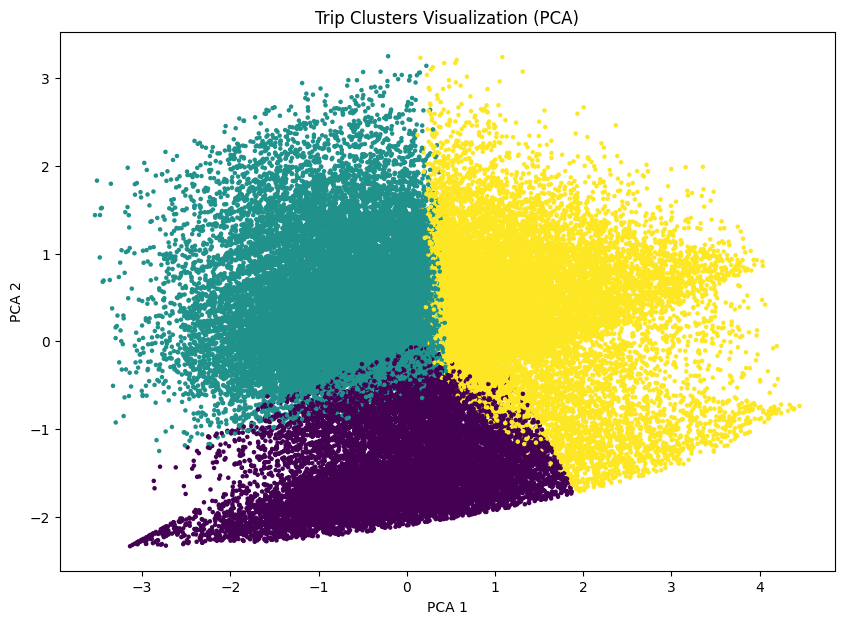

In [270]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# reduce dimensions
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

# plot
plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=sample_trip["cluster"],
    s=5
)

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Trip Clusters Visualization (PCA)")

plt.show()

In [272]:
sample_trip["cluster"].value_counts(normalize=True)

cluster
1    0.473613
2    0.288685
0    0.237702
Name: proportion, dtype: float64

In [271]:
cluster_profile = (
    sample_trip
    .groupby("cluster")[
        [
            "trip_distance",
            "avg_speed_mph",
            "tip_rate_pct"
        ]
    ]
    .mean()
)

print(cluster_profile)

         trip_distance  avg_speed_mph  tip_rate_pct
cluster                                            
0             0.829338       7.059105      4.047294
1             0.742056       6.939643     31.352895
2             1.289840      11.542052     23.227880


In [274]:
zone_cluster = (
    sample_trip
    .groupby(["pickup_zone", "cluster"])
    .size()
    .reset_index(name="count")
)
zone_cluster

,pickup_zone,cluster,count
0,Allerton/Pelham Gardens,0,1
1,Alphabet City,0,13
2,Alphabet City,1,17
3,Alphabet City,2,28
4,Astoria,0,10
...,...,...,...
393,Yorkville East,1,344
394,Yorkville East,2,268
395,Yorkville West,0,256
396,Yorkville West,1,509
